In [41]:
import gc
gc.collect()

40

In [42]:
import nibabel as nib
import numpy as np
from pathlib import Path
from tqdm import tqdm
from file_manager import preprocess_file_manager
from visualization_lib import folder_shower

In [43]:
data_folder =  '/home/robakp/Exeriments1/prostate_lesion_detection/rjozwiak-MGR_dataset_correct/MGR_dataset_correct'

channels = {
    'adc' : 'adc',
    'anatomy' : 'anatomy',
    'dwi' : 'dwi',
    't2' : 't2'
}

target = 'lesion'

file_extention = '.nii.gz'

preprocessed_steps = [
    'raw',
    'filling_anatomy_gaps'
]


In [44]:
import SimpleITK as sitk

def register_and_resample(moving, reference, interpolator=sitk.sitkLinear):
    """Register moving image to reference and resample."""
    
    transform = sitk.CenteredTransformInitializer(
        reference,
        moving,
        sitk.Euler3DTransform(),
        sitk.CenteredTransformInitializerFilter.GEOMETRY
    )

    resampled = sitk.Resample(
        moving,
        reference,
        transform,
        interpolator,
        0.0,
        moving.GetPixelID()
    )

    return resampled

In [45]:
def get_all_patients_ids(data_path):
    folder = Path(data_folder)
    ids = []
    for patient in folder.iterdir():
        ids.append(patient.name)
    return ids


Check of Patients 

In [46]:
# resample_channels = ['adc','dwi'],resample_to = 't2'

In [47]:
def load_patient(data_path,patient,resample_channels = [],resample_to = 't2'):

    scikit_images = {}
    patient_path = data_path / Path(patient)
    if patient_path.is_dir():
        
        ##
        for key in channels:
            channel_file = patient_path / f"{channels[key]}.nii.gz"
            image = sitk.ReadImage(str(channel_file))
            scikit_images[key]= image
        ##
        for key in resample_channels:
            print("ERROR ERROR")
            scikit_images[key] = register_and_resample(scikit_images[key],scikit_images[resample_to])  
        
        ##transform to just data
        patient_data = {}
        for channel in scikit_images:
            patient_data[channel] = sitk.GetArrayFromImage(scikit_images[channel])
            #sus transpose
            patient_data[channel] = np.transpose(patient_data[channel], (2, 1, 0))
    return patient_data

In [48]:
patients = get_all_patients_ids(data_folder)

In [49]:
def load_raw_data_and_register(data_folder,resample_to = 't2',resample_channels = ['adc','dwi']):
    data = {}
    folder = Path(data_folder)

    patients_folders = [x for x in folder.iterdir()]


    for patient in tqdm(patients_folders):
        data[patient.name] = load_patient(data_folder,patient)
    return data


In [50]:
# load_raw_data_and_register(data_folder)

In [51]:
patients = get_all_patients_ids(data_folder)

dispaly

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [53]:
def normalize_volume(volume):
    vmin = volume.min()
    vmax = volume.max()
    if vmax - vmin == 0:
        return np.zeros_like(volume)
    return (volume - vmin) / (vmax - vmin)

In [54]:
file_manager = preprocess_file_manager('/home/robakp/Exeriments1/prostate_lesion_detection/juzwiak_preprocessed',preprocessed_steps)

In [55]:
folder_shower(file_manager,'raw',normalize_volume)

AttributeError: 'function' object has no attribute 'keys'

remember about allingning

How to detect if prostate even is on picture? Is this in data? I think it is

In [ ]:

folder = Path(data_folder)

for patient in folder.iterdir():
    if patient.is_dir():
        patient_data = load_patient(data_folder,patient.name)
        file_manager.save_file('raw', patient.name, patient_data)

check how big portions with prostate are

In [ ]:
def find_periods(arr):
    if len(arr) == 0:
        return []

    periods = []
    start = arr[0]
    prev = arr[0]

    for num in arr[1:]:
        if num == prev + 1:
            prev = num
        else:
            periods.append((start, prev))
            start = num
            prev = num

    periods.append((start, prev))
    return periods

In [ ]:
for patient in patients[:1]:
    print(patient)
    prostate = file_manager.load_file('raw',patient)['anatomy'] 
    valid_layers = np.any(prostate == 1, axis=(0, 1))
    print(valid_layers.shape)

3322
(41,)


Working with holes in prostate layer

In [ ]:
true_indices = np.where(valid_layers)[0]
print(true_indices)
print(len(find_periods(true_indices)))

[15 16 17 18 19 20 22 23 24 25 26 27 28 29 30]
2


In [ ]:
def find_gaps_in_anatomy(patients,file_manager,step = 'raw'):
    outliers = []
    sections_with_prostate = {}
    for patient in patients:
        prostate = file_manager.load_file(step, patient)['anatomy'] 
        valid_layers = np.any(prostate == 1, axis=(0, 1))
        true_indices = np.where(valid_layers)[0]
        if len(find_periods(true_indices)) != 1:
            outliers.append(patient)
        periods = find_periods(true_indices)
        if len(periods) >= 0:
            sections_with_prostate[patient] = (periods[0][0], periods[-1][1])
        else:
            raise ValueError(f"Patient {patient} without anatomy data")
    return outliers,sections_with_prostate

outliers,sections_with_prostate = find_gaps_in_anatomy(patients,file_manager)

checking out outliers

In [ ]:
for outlier in outliers:
    print(outlier)
    prostate = file_manager.load_file('raw',outlier)['anatomy'] 
    valid_layers = np.any(prostate == 1, axis=(0, 1))
    true_indices = np.where(valid_layers)[0]
    periods = find_periods(true_indices)
    print(len(periods))
    print(periods)

3322
2
[(15, 20), (22, 30)]
432
2
[(14, 17), (19, 25)]
524
2
[(13, 18), (21, 22)]
798
2
[(13, 19), (21, 21)]
696
2
[(13, 17), (19, 23)]
1038
2
[(16, 18), (20, 26)]
534
2
[(17, 17), (19, 32)]
1183
2
[(9, 13), (15, 18)]
906
2
[(9, 14), (16, 18)]
655
2
[(15, 19), (21, 29)]


In [ ]:
import numpy as np
from scipy.ndimage import distance_transform_edt

def signed_distance(mask):
    mask = mask.astype(bool)
    outside = distance_transform_edt(~mask)
    inside = distance_transform_edt(mask)
    return outside - inside

def interpolate_shapes(A, B, steps):
    dA = signed_distance(A)
    dB = signed_distance(B)
    result = []
    for i in range(1, steps + 1):
        t = i / (steps + 1)
        d = (1 - t) * dA + t * dB
        result.append((d < 0).astype(int))
    return result

A = np.array([[0, 1, 1, 1, 1, 1],
              [0, 1, 1, 1, 1, 1],
              [0, 1, 1, 1, 1, 1],
              [0, 1, 1, 1, 1, 1],
              [0, 1, 1, 1, 1, 1],
              [0, 0, 0, 0, 0, 0]])

B = np.array([[0, 0, 0, 0, 0, 1],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0]])

frames = interpolate_shapes(A, B, 3)

In [ ]:
outlier = '524'
def fix_patient_anatomy(outlier, file_manager,step = 'raw'):
    outlier_data = file_manager.load_file(step, outlier)
    prostate = outlier_data['anatomy']
    valid_layers = np.any(prostate == 1, axis=(0, 1))
    true_indices = np.where(valid_layers)[0]
    i = 0
    periods = find_periods(true_indices)
    while i < len(periods)-1:
        start = periods[i][1]
        end = periods[i+1][0]
        print(f"{start}  {end}")

        start_layer = prostate[:,:,start]
        end_layer = prostate[:,:,end]
        number_of_interpolation_layers = end-start-1

        new_leayers = interpolate_shapes(start_layer,end_layer,number_of_interpolation_layers)

        j = start+1
        while j <  end:
            prostate[:,:,j] = new_leayers[j-start-1]
            j+=1
        i+=1
    file_manager.save_file(step,outlier,outlier_data)

    

fix_patient_anatomy(outlier, file_manager)

18  21


In [ ]:
outliers, _ = find_gaps_in_anatomy(patients,file_manager)
print(outliers)
for outlier in outliers:
    fix_patient_anatomy(outlier,file_manager)

e, sections_with_prostate  = find_gaps_in_anatomy(patients,file_manager)
print(e)

['3322', '432', '798', '696', '1038', '534', '1183', '906', '655']
20  22
17  19
19  21
17  19
18  20
17  19
13  15
14  16
19  21
[]


Cutting pictures into correct sizes

checking size

In [ ]:
biggest_gap = (0, -1, 0)
smallest_gap = (0,99999, 0)
for patient in sections_with_prostate:
    diff = sections_with_prostate[patient][1] - sections_with_prostate[patient][0] + 1
    if diff > biggest_gap[1]:
        biggest_gap = (patient,diff,sections_with_prostate[patient])
    if diff < smallest_gap[1]:
        smallest_gap = (patient,diff,sections_with_prostate[patient])

print(biggest_gap)
print(smallest_gap)

('482', 27, (13, 39))
('3071', 4, (15, 18))


looking for smallest picture

In [ ]:
def find_smallest_dimensions_of_3D_arrays(patients):
    smallest_dim = [9999 for x in range (0,3)]

    for patient in patients:
        data = file_manager.load_file('raw', patient)
        shape_per_channel = [data[channel].shape for channel in channels]

        all_same = len(set(shape_per_channel)) == 1
        if not all_same:
            print(f"ALERT ALERT {patient}")

        for i in range(0,3):
            dim = shape_per_channel[0][i]
            if smallest_dim[i] > dim:
                smallest_dim[i] = dim
    return smallest_dim

smallest_dim = find_smallest_dimensions_of_3D_arrays(patients)
for i in range(0,3):
    print(f"smallest dim{i} {smallest_dim[i]}")

    

smallest dim0 256
smallest dim1 256
smallest dim2 25


two ways of centering

In [ ]:
import statistics as stats
def find_centroid_mean(figure):
    coords = np.argwhere(figure == 1)
    centroid = coords.mean(axis=0)
    return centroid

def find_figure_box(figure):
    idx = np.where(figure == 1)
    min_indices = [i.min() for i in idx]
    max_indices = [i.max() for i in idx]
    return min_indices, max_indices

def find_centroid_non_weighted(figure):
    min_indices, max_indices = find_figure_box(figure)
    return [np.mean([min_indices[i],max_indices[i]]) for i in range (0,len(max_indices))]
    

np_centroid = find_centroid_mean(prostate)
print("Np Centroid:", np_centroid)


non_weighted_centroid = find_centroid_non_weighted(prostate)
print("Np Centroid:", non_weighted_centroid)



Np Centroid: [154.77185221 156.30973734  21.18577863]
Np Centroid: [156.0, 156.5, 22.0]


finding maximum prostate dimentions

In [ ]:
step = 'raw'

def find_patients_max_prostate_sizes(patients,step = 'raw'):
    maximum_prostate_size = [0,0,0]
    for patient in patients:
        prostate = file_manager.load_file(step, patient)['anatomy']
        borders = find_figure_box(prostate)
        prostate_size= [ borders[1][i] - borders[0][i]+1 for i in range (0,len(borders[0]))]
        for dim, size in enumerate(prostate_size):
            if (size > maximum_prostate_size[dim]):
                maximum_prostate_size[dim] = size
    return maximum_prostate_size

maximum_prostate_size = find_patients_max_prostate_sizes(patients)
print(maximum_prostate_size)

KeyboardInterrupt: 

center cropping

In [ ]:
new_size = (160,160,24)
chosen_patient = '001'

In [ ]:
def center_crop_shift(figure, center, crop_size):
    shape = figure.shape
    start = [int(c - s//2) for c, s in zip(center, crop_size)]
    end = [start[i] + crop_size[i] for i in range(3)]

    for i in range(3):
        if start[i] < 0:
            end[i] -= start[i]
            start[i] = 0
        if end[i] > shape[i]:
            start[i] -= end[i] - shape[i]
            end[i] = shape[i]

    return figure[start[0]:end[0], start[1]:end[1], start[2]:end[2]]

In [ ]:
data = file_manager.load_file(step, chosen_patient)
center = find_centroid_non_weighted(data['anatomy'])
shifted_data = center_crop_shift(data['anatomy'],center,new_size)


In [ ]:
def show_transformation(dictionary):
    n = len(dictionary)
    plt.figure(figsize=(5*n, 5))

    for i, (name, img) in enumerate(dictionary.items(), 1):
        plt.subplot(1, n, i)
        plt.imshow(img, cmap='gray', vmin=0, vmax=1)
        plt.title(name)
        plt.axis('off')

    plt.show()

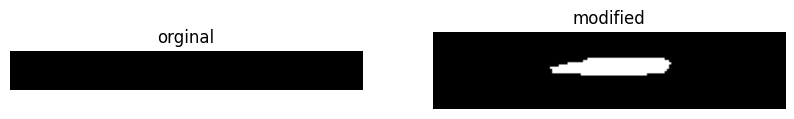

In [ ]:
data_to_show = {
    'orginal' : normalize_volume(load_patient(data_folder,chosen_patient)['anatomy'][:, :, 12]),
    'modified' : shifted_data[:,:,9],
}
show_transformation(data_to_show)

THERE IS NO PADDING!!!!

In [ ]:
step = 'raw'

for patient in patients:

    data = file_manager.load_file(step, patient)
    center = find_centroid_non_weighted(data['anatomy'])
    for channel in data:
        data[channel] = center_crop_shift(data[channel],center,new_size)
    
    file_manager.save_file('cropped',patient,data)
    

In [ ]:
folder_shower(file_manager)
folder_shower(file_manager,step = 'cropped')

interactive(children=(Dropdown(description='Patient:', options=('001', '003', '004', '005', '007', '008', '011…

interactive(children=(Dropdown(description='Patient:', options=('001', '003', '004', '005', '007', '008', '011…